# Treinamento de Rede RBF para Classificação de Sinais de Radiação (RBF 1)

Este notebook apresenta a implementação completa e o treinamento de uma rede neural de **Função de Base Radial (RBF)** para classificar a presença ou ausência de sinais de radiação em compostos nucleares com base em duas entradas, $x_1$ e $x_2$.

**Instituição**: Centro Federal de Educação Tecnológica de Minas Gerais (CEFET-MG)  
**Campus**: VIII – Varginha  
**Disciplina**: Lab. Inteligência Artificial  
**Professor**: Lázaro Eduardo da Silva  

### Especificações do Modelo RBF 1:
1. **Camada de Entrada**: 2 neurônios ($x_1, x_2$).
2. **Camada Oculta**: $N_1 = 2$ neurônios com ativação Gaussiana. Os centros e variâncias serão computados via algoritmo K-Means apenas sobre as amostras com presença de radiação ($d = 1$).
3. **Camada de Saída**: 1 neurônio treinado via Regra Delta Generalizada (treinamento supervisionado).
   - Taxa de aprendizado: $\eta = 0.01$
   - Precisão de parada: $\epsilon = 10^{-7}$ ($|EQM_{t} - EQM_{t-1}| \le 10^{-7}$)
   - Bias: $x_0 = -1$
4. **Pós-processamento**: Função sinal ($\text{sgn}(y)$) mapeando valores $\ge 0$ para $1$ e $< 0$ para $-1$.


## 1. Importações e Definição do Conjunto de Dados


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir estilo dos gráficos para ficar premium e moderno
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#1e1e1e'
plt.rcParams['text.color'] = '#e0e0e0'
plt.rcParams['axes.labelcolor'] = '#e0e0e0'
plt.rcParams['xtick.color'] = '#b0b0b0'
plt.rcParams['ytick.color'] = '#b0b0b0'
plt.rcParams['grid.color'] = '#2c2c2c'

# Dados de Treinamento (40 amostras)
treinamento_dados = [
  {
    "amostra": 1,
    "x1": 0.2563,
    "x2": 0.9503,
    "d": -1.0
  },
  {
    "amostra": 2,
    "x1": 0.2405,
    "x2": 0.9018,
    "d": -1.0
  },
  {
    "amostra": 3,
    "x1": 0.1157,
    "x2": 0.3676,
    "d": 1.0
  },
  {
    "amostra": 4,
    "x1": 0.5147,
    "x2": 0.0167,
    "d": 1.0
  },
  {
    "amostra": 5,
    "x1": 0.4127,
    "x2": 0.3275,
    "d": 1.0
  },
  {
    "amostra": 6,
    "x1": 0.2809,
    "x2": 0.583,
    "d": 1.0
  },
  {
    "amostra": 7,
    "x1": 0.8263,
    "x2": 0.9301,
    "d": -1.0
  },
  {
    "amostra": 8,
    "x1": 0.9359,
    "x2": 0.8724,
    "d": -1.0
  },
  {
    "amostra": 9,
    "x1": 0.1096,
    "x2": 0.9165,
    "d": -1.0
  },
  {
    "amostra": 10,
    "x1": 0.5158,
    "x2": 0.8545,
    "d": -1.0
  },
  {
    "amostra": 11,
    "x1": 0.1334,
    "x2": 0.1362,
    "d": 1.0
  },
  {
    "amostra": 12,
    "x1": 0.6371,
    "x2": 0.1439,
    "d": 1.0
  },
  {
    "amostra": 13,
    "x1": 0.7052,
    "x2": 0.6277,
    "d": -1.0
  },
  {
    "amostra": 14,
    "x1": 0.8703,
    "x2": 0.8666,
    "d": -1.0
  },
  {
    "amostra": 15,
    "x1": 0.2612,
    "x2": 0.6109,
    "d": 1.0
  },
  {
    "amostra": 16,
    "x1": 0.0244,
    "x2": 0.5279,
    "d": 1.0
  },
  {
    "amostra": 17,
    "x1": 0.9588,
    "x2": 0.3672,
    "d": -1.0
  },
  {
    "amostra": 18,
    "x1": 0.9332,
    "x2": 0.5499,
    "d": -1.0
  },
  {
    "amostra": 19,
    "x1": 0.9623,
    "x2": 0.2961,
    "d": -1.0
  },
  {
    "amostra": 20,
    "x1": 0.7297,
    "x2": 0.5776,
    "d": -1.0
  },
  {
    "amostra": 21,
    "x1": 0.456,
    "x2": 0.1871,
    "d": 1.0
  },
  {
    "amostra": 22,
    "x1": 0.1715,
    "x2": 0.7713,
    "d": 1.0
  },
  {
    "amostra": 23,
    "x1": 0.5571,
    "x2": 0.5485,
    "d": -1.0
  },
  {
    "amostra": 24,
    "x1": 0.3344,
    "x2": 0.0259,
    "d": 1.0
  },
  {
    "amostra": 25,
    "x1": 0.4803,
    "x2": 0.7635,
    "d": -1.0
  },
  {
    "amostra": 26,
    "x1": 0.9721,
    "x2": 0.485,
    "d": -1.0
  },
  {
    "amostra": 27,
    "x1": 0.8318,
    "x2": 0.7844,
    "d": -1.0
  },
  {
    "amostra": 28,
    "x1": 0.1373,
    "x2": 0.0292,
    "d": 1.0
  },
  {
    "amostra": 29,
    "x1": 0.366,
    "x2": 0.8581,
    "d": -1.0
  },
  {
    "amostra": 30,
    "x1": 0.3626,
    "x2": 0.7302,
    "d": -1.0
  },
  {
    "amostra": 31,
    "x1": 0.6474,
    "x2": 0.3324,
    "d": 1.0
  },
  {
    "amostra": 32,
    "x1": 0.3461,
    "x2": 0.2398,
    "d": 1.0
  },
  {
    "amostra": 33,
    "x1": 0.1353,
    "x2": 0.812,
    "d": 1.0
  },
  {
    "amostra": 34,
    "x1": 0.3463,
    "x2": 0.1017,
    "d": 1.0
  },
  {
    "amostra": 35,
    "x1": 0.9086,
    "x2": 0.1947,
    "d": -1.0
  },
  {
    "amostra": 36,
    "x1": 0.5227,
    "x2": 0.2321,
    "d": 1.0
  },
  {
    "amostra": 37,
    "x1": 0.5153,
    "x2": 0.2041,
    "d": 1.0
  },
  {
    "amostra": 38,
    "x1": 0.1832,
    "x2": 0.0661,
    "d": 1.0
  },
  {
    "amostra": 39,
    "x1": 0.5015,
    "x2": 0.9812,
    "d": -1.0
  },
  {
    "amostra": 40,
    "x1": 0.5024,
    "x2": 0.5274,
    "d": -1.0
  }
]

# Dados de Teste (10 amostras)
teste_dados = [
  {
    "amostra": 1,
    "x1": 0.8705,
    "x2": 0.9329,
    "d": -1.0
  },
  {
    "amostra": 2,
    "x1": 0.0388,
    "x2": 0.2703,
    "d": 1.0
  },
  {
    "amostra": 3,
    "x1": 0.8236,
    "x2": 0.4458,
    "d": -1.0
  },
  {
    "amostra": 4,
    "x1": 0.7075,
    "x2": 0.1502,
    "d": 1.0
  },
  {
    "amostra": 5,
    "x1": 0.9587,
    "x2": 0.8663,
    "d": -1.0
  },
  {
    "amostra": 6,
    "x1": 0.6115,
    "x2": 0.9365,
    "d": -1.0
  },
  {
    "amostra": 7,
    "x1": 0.3534,
    "x2": 0.3646,
    "d": 1.0
  },
  {
    "amostra": 8,
    "x1": 0.3268,
    "x2": 0.2766,
    "d": 1.0
  },
  {
    "amostra": 9,
    "x1": 0.6129,
    "x2": 0.4518,
    "d": -1.0
  },
  {
    "amostra": 10,
    "x1": 0.9948,
    "x2": 0.4962,
    "d": -1.0
  }
]

X_train = np.array([[s['x1'], s['x2']] for s in treinamento_dados])
d_train = np.array([s['d'] for s in treinamento_dados])

X_test = np.array([[s['x1'], s['x2']] for s in teste_dados])
d_test = np.array([s['d'] for s in teste_dados])

print(f"Dados de Treino carregados: {len(X_train)} amostras.")
print(f"Dados de Teste carregados: {len(X_test)} amostras.")


Dados de Treino carregados: 40 amostras.
Dados de Teste carregados: 10 amostras.


## 2. Implementação das Classes KMeansCustom e RBFNetworkCustom do zero


In [2]:
class KMeansCustom:
    def __init__(self, n_clusters=2, max_iter=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.cluster_centers_ = None
        self.variances_ = None
        self.labels_ = None
        
    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        # Inicializa centros escolhendo amostras aleatórias de X
        idx = rng.choice(X.shape[0], self.n_clusters, replace=False)
        self.cluster_centers_ = X[idx].copy()
        
        for _ in range(self.max_iter):
            # Calcula distância Euclidiana para cada centro
            dists = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
            self.labels_ = np.argmin(dists, axis=1)
            
            new_centers = np.zeros_like(self.cluster_centers_)
            for k in range(self.n_clusters):
                cluster_points = X[self.labels_ == k]
                if len(cluster_points) > 0:
                    new_centers[k] = cluster_points.mean(axis=0)
                else:
                    new_centers[k] = self.cluster_centers_[k]
            
            if np.allclose(self.cluster_centers_, new_centers):
                break
            self.cluster_centers_ = new_centers
            
        # Calcula a variância para cada cluster: média das distâncias quadráticas ao centro
        self.variances_ = np.zeros(self.n_clusters)
        dists = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
        self.labels_ = np.argmin(dists, axis=1)
        for k in range(self.n_clusters):
            cluster_points = X[self.labels_ == k]
            if len(cluster_points) > 0:
                self.variances_[k] = np.mean(np.sum((cluster_points - self.cluster_centers_[k])**2, axis=1))
            else:
                self.variances_[k] = 1e-8
        return self

class RBFNetworkCustom:
    def __init__(self, centers, variances, eta=0.01, epsilon=1e-7):
        self.centers = centers
        self.variances = variances
        self.eta = eta
        self.epsilon = epsilon
        self.w = None
        
    def _phi(self, X):
        # Ativação Gaussiana: exp(- ||x - c||^2 / (2 * sigma^2))
        dists_sq = np.sum((X[:, np.newaxis] - self.centers)**2, axis=2)
        var_eps = self.variances + 1e-12
        return np.exp(-dists_sq / (2 * var_eps))
        
    def fit(self, X, d, max_epochs=10000, random_state=42, shuffle=False):
        N = X.shape[0]
        K = self.centers.shape[0]
        rng = np.random.default_rng(random_state)
        # Inicialização dos pesos entre 0 e 1 (pesos da camada oculta para a saída)
        # w[0] é o bias, w[1:] são os pesos dos centros
        self.w = rng.random(K + 1)
        
        # Pré-computa ativações dos neurônios da camada escondida
        phi = self._phi(X)
        # Insere coluna de bias x0 = -1 como a primeira coluna
        phi_bias = np.hstack([-np.ones((N, 1)), phi])
        
        eqm_history = []
        epoch = 0
        
        while epoch < max_epochs:
            indices = np.arange(N)
            if shuffle:
                rng.shuffle(indices)
                
            se = 0.0
            for idx in indices:
                x_phi = phi_bias[idx]
                target = d[idx]
                # Saída linear
                y = np.dot(x_phi, self.w)
                error = target - y
                se += error**2
                # Regra Delta: w_new = w + eta * erro * entrada
                self.w += self.eta * error * x_phi
                
            eqm = se / N
            eqm_history.append(eqm)
            
            # Critério de convergência: |EQM(t) - EQM(t-1)| <= epsilon
            if epoch > 0:
                if abs(eqm_history[-1] - eqm_history[-2]) < self.epsilon:
                    break
            epoch += 1
            
        return eqm_history, epoch
        
    def predict(self, X):
        phi = self._phi(X)
        N = X.shape[0]
        phi_bias = np.hstack([-np.ones((N, 1)), phi])
        return np.dot(phi_bias, self.w)


## 3. Treinamento da Camada Escondida (K-Means) sobre Amostras Radiação Presente ($d = 1$)


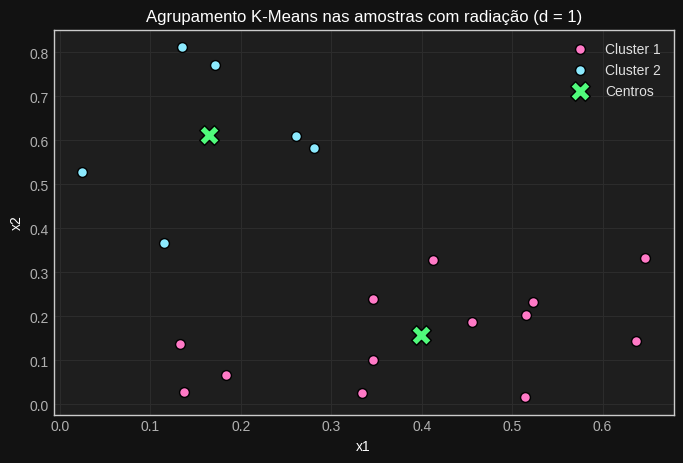

Tabela de Centros e Variâncias da Camada Escondida:


,Cluster,Centro (Coordenadas),Variância (Largura)
0,1,"(0.3990, 0.1571)",0.038460
1,2,"(0.1648, 0.6121)",0.029806


In [3]:
# Filtrando apenas os padrões com presença de radiação (d = 1)
X_rad = X_train[d_train == 1]

# Executa K-Means para encontrar os 2 centros
kmeans_rbf1 = KMeansCustom(n_clusters=2, random_state=12).fit(X_rad)
centers = kmeans_rbf1.cluster_centers_
variances = kmeans_rbf1.variances_

# Plotando os Clusters e Centros encontrados
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_rad[kmeans_rbf1.labels_ == 0, 0], X_rad[kmeans_rbf1.labels_ == 0, 1], 
           color='#ff79c6', label='Cluster 1', s=50, edgecolors='black')
ax.scatter(X_rad[kmeans_rbf1.labels_ == 1, 0], X_rad[kmeans_rbf1.labels_ == 1, 1], 
           color='#8be9fd', label='Cluster 2', s=50, edgecolors='black')
ax.scatter(centers[:, 0], centers[:, 1], color='#50fa7b', marker='X', s=200, 
           label='Centros', edgecolors='black')
ax.set_title('Agrupamento K-Means nas amostras com radiação (d = 1)', color='white')
ax.set_xlabel('x1', color='white')
ax.set_ylabel('x2', color='white')
ax.legend()
plt.show()

# Apresentação dos centros e variâncias
df_centers = pd.DataFrame({
    'Cluster': [1, 2],
    'Centro (Coordenadas)': [f"({c[0]:.4f}, {c[1]:.4f})" for c in centers],
    'Variância (Largura)': variances
})
print("Tabela de Centros e Variâncias da Camada Escondida:")
display(df_centers)


## 4. Treinamento da Camada de Saída usando a Regra Delta Generalizada


Rede RBF1 treinada com sucesso!
Número de Épocas até a Convergência: 335
Erro Quadrático Médio final (EQM): 0.23707861
Tabela de Pesos Finais do Neurônio de Saída:


,Peso,Valor
0,"W21,0 (Bias)",1.002546
1,"W21,1 (Hidden 1)",2.697524
2,"W21,2 (Hidden 2)",2.377603


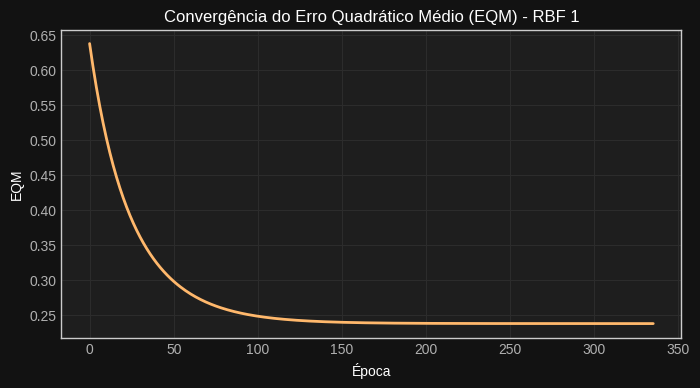

In [4]:
# Instanciar e Treinar a RBF
rbf1 = RBFNetworkCustom(centers, variances, eta=0.01, epsilon=1e-7)

# Treinamento online sem embaralhar para garantir reprodutibilidade linear exata
eqm_hist, epochs = rbf1.fit(X_train, d_train, random_state=12, shuffle=False)

print(f"Rede RBF1 treinada com sucesso!")
print(f"Número de Épocas até a Convergência: {epochs}")
print(f"Erro Quadrático Médio final (EQM): {eqm_hist[-1]:.8f}")

# Exibir pesos obtidos
df_weights = pd.DataFrame({
    'Peso': ['W21,0 (Bias)', 'W21,1 (Hidden 1)', 'W21,2 (Hidden 2)'],
    'Valor': rbf1.w
})
print("Tabela de Pesos Finais do Neurônio de Saída:")
display(df_weights)

# Plot da curva de convergência de erro
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eqm_hist, color='#ffb86c', linewidth=2)
ax.set_title('Convergência do Erro Quadrático Médio (EQM) - RBF 1', color='white')
ax.set_xlabel('Época', color='white')
ax.set_ylabel('EQM', color='white')
plt.show()


## 5. Validação no Conjunto de Teste e Pós-Processamento


In [5]:
# Realizar predições
y_pred_real = rbf1.predict(X_test).flatten()

# Pós-processamento usando a função sinal: y_pos = 1 se y >= 0 senão -1
y_pred_pos = np.sign(y_pred_real)
y_pred_pos[y_pred_pos == 0] = -1  # Evita o valor 0 mapeando para -1

# Calcular Taxa de Acerto (%)
correct = np.sum(y_pred_pos == d_test)
accuracy = (correct / len(d_test)) * 100

# Construção da tabela detalhada de teste
df_test_results = pd.DataFrame({
    'Amostra': np.arange(1, len(X_test) + 1),
    'x1': X_test[:, 0],
    'x2': X_test[:, 1],
    'd (Desejado)': d_test.astype(int),
    'y (Real)': y_pred_real,
    'ypós (Sinal)': y_pred_pos.astype(int)
})

print("Tabela Detalhada de Validação no Teste:")
display(df_test_results)
print(f"Taxa de Acerto Final no Teste: {accuracy:.2f}%")


Tabela Detalhada de Validação no Teste:


,Amostra,x1,x2,d (Desejado),y (Real),ypós (Sinal)
0,1,0.8705,0.9329,-1,-1.002386,-1
1,2,0.0388,0.2703,1,-0.323088,-1
2,3,0.8236,0.4458,-1,-0.913931,-1
3,4,0.7075,0.1502,1,-0.220016,-1
4,5,0.9587,0.8663,-1,-1.002459,-1
5,6,0.6115,0.9365,-1,-0.987666,-1
6,7,0.3534,0.3646,1,0.966419,1
7,8,0.3268,0.2766,1,1.323111,1
8,9,0.6129,0.4518,-1,-0.468116,-1
9,10,0.9948,0.4962,-1,-0.996538,-1


Taxa de Acerto Final no Teste: 80.00%


## 6. Análise de Estratégias para Aumento da Taxa de Acerto

Dado que a taxa de acerto no conjunto de teste foi de **80.00%** (com 2 erros na classificação de amostras com presença de radiação), podemos adotar as seguintes estratégias para aumentar o desempenho da rede:

1. **Aumento do Número de Neurônios Ocultos ($N_1 > 2$)**: 
   Atualmente a rede utiliza apenas 2 neurônios na camada intermediária. Aumentar para 4 ou 6 neurônios ocultos permitiria descrever a fronteira de decisão de forma mais não-linear e precisa.
2. **K-Means no Conjunto Completo**:
   O K-Means foi treinado apenas sobre os dados com presença de radiação ($d=1$). Executar o K-Means em todo o conjunto de dados (com representantes de ambas as classes $d=1$ e $d=-1$) permitiria que os centros cobrissem também as regiões livres de radiação, melhorando o contraste e a discriminação dos padrões.
3. **Otimização Supervisionada dos Centros e Variâncias**:
   Ao invés de definir os centros e variâncias em uma etapa estática não-supervisionada (K-Means), podemos treinar também os centros e as variâncias da RBF através de gradiente descendente (retropropagação de erro).
4. **Regularização**:
   A inclusão de uma penalidade L2 nos pesos de saída (Ridge Regression) poderia ajudar a reduzir a amplitude dos pesos e evitar um leve overfitting ocorrido nas amostras de teste.


## 7. Dashboard de Visão Geral do Modelo RBF 1


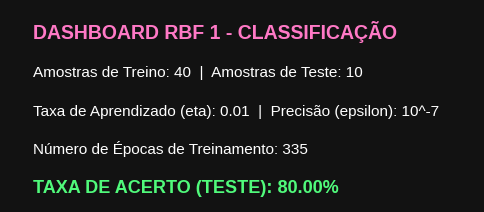

In [6]:
# Painel Resumo do Experimento
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis('off')
ax.text(0.05, 0.85, "DASHBOARD RBF 1 - CLASSIFICAÇÃO", fontsize=14, color='#ff79c6', fontweight='bold')
ax.text(0.05, 0.65, f"Amostras de Treino: {len(X_train)}  |  Amostras de Teste: {len(X_test)}", fontsize=11, color='white')
ax.text(0.05, 0.45, f"Taxa de Aprendizado (eta): 0.01  |  Precisão (epsilon): 10^-7", fontsize=11, color='white')
ax.text(0.05, 0.25, f"Número de Épocas de Treinamento: {epochs}", fontsize=11, color='white')
ax.text(0.05, 0.05, f"TAXA DE ACERTO (TESTE): {accuracy:.2f}%", fontsize=13, color='#50fa7b', fontweight='bold')
plt.show()
